In [1]:
import tensorflow as tf

import os
from pathlib import Path
import datetime
import numpy as np

from IPython.display import display, clear_output
from tqdm.notebook import tqdm

from fid import get_frechet_inception_distance
import pandas as pd

from normalize import images_from_normalized
from preprocess import FrameDataGenerator, PreprocessedFrameDataGenerator
from plot import plot_normalized_sequence, generate_sequences, plot_results
from model import get_generator_model, get_discriminator_model
from loss import l1_loss, euclidean_distance, GeneratorLoss, DiscriminatorLoss, pairwise_loss
from landmarks import DlibLandmarksDetector

2023-06-16 16:16:26.914619: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2023-06-16 16:16:26.963392: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
COHERENCE_LOSS = l1_loss # TODO: loss function not working, fix: str > function
MAIN_LOSS = l1_loss
LANDMARKS_LOSS = None
LANDMARKS_COHERENCE_LOSS = l1_loss

# Dimensions
r = 64
# BATCH_SIZE = 100 # TODO: Allow only 1 frame input
IMG_WIDTH = r
IMG_HEIGHT = r
N_CHANNELS = 3

N_LANDMARKS = 68


STEPS = 100000
# STEPS = STEPS // BATCH_SIZE
STEPS = STEPS // 100

LAMBDA1 = 1000
LAMBDA2 = 200
LAMBDA3 = 100
LAMBDA4 = 10

VIDEOS_FOLDER = f'mug{r}'
BASE_PATH = Path('../')
DATA_PATH = BASE_PATH / 'data'
APP_PATH = BASE_PATH / 'app'


## Load the dataset

In [3]:
videos_path = list((DATA_PATH / VIDEOS_FOLDER).glob('**/*.npy'))

In [4]:
DATASET_SIZE = len(videos_path)
train_size = int(0.7 * DATASET_SIZE)
# val_size = int(0.15 * DATASET_SIZE)
test_size = int(0.3 * DATASET_SIZE)

# generate training, validation and test sets
train_paths = videos_path[:train_size]
# val_sequences = sequences[train_size:train_size+val_size]
# test_sequences = sequences[train_size+val_size:]
test_paths = videos_path[train_size:]

tf.print(len(train_paths))
tf.print(len(test_paths))

train_paths = train_paths[:10]

722
310


2023-06-16 16:16:31.947219: E tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:266] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2023-06-16 16:16:31.947296: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:168] retrieving CUDA diagnostic information for host: 9900cbbf9a77
2023-06-16 16:16:31.947316: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:175] hostname: 9900cbbf9a77
2023-06-16 16:16:31.947496: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:199] libcuda reported version is: NOT_FOUND: was unable to find libcuda.so DSO loaded into this program
2023-06-16 16:16:31.947548: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:203] kernel reported version is: 525.105.17


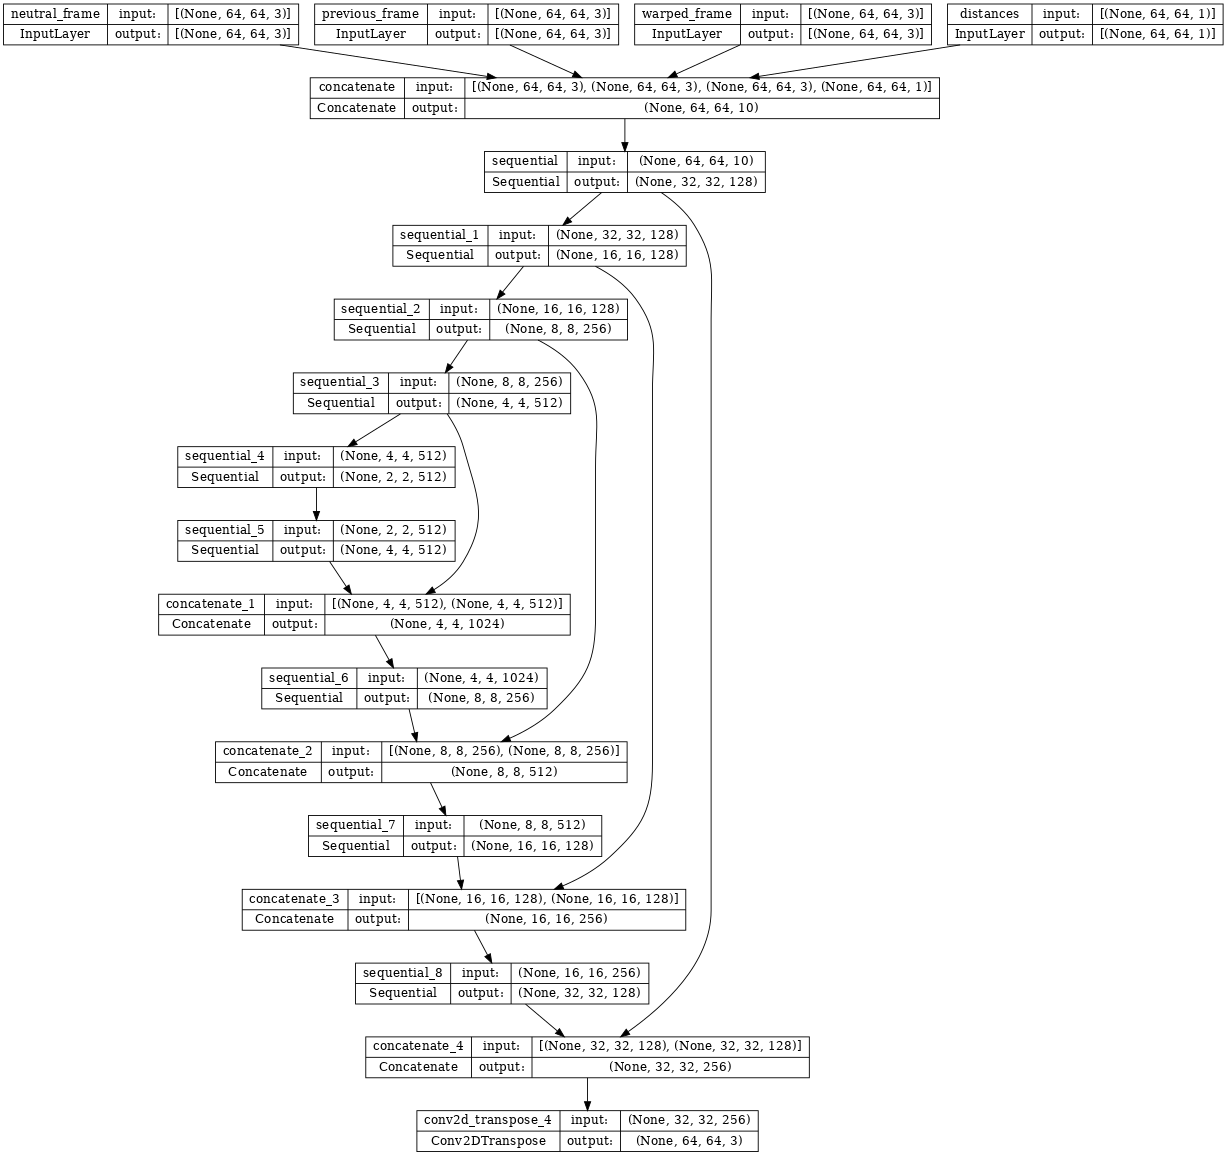

In [5]:
generator = get_generator_model(IMG_WIDTH, IMG_HEIGHT, N_CHANNELS)
tf.keras.utils.plot_model(generator, show_shapes=True, dpi=64, to_file='output/generator.png')

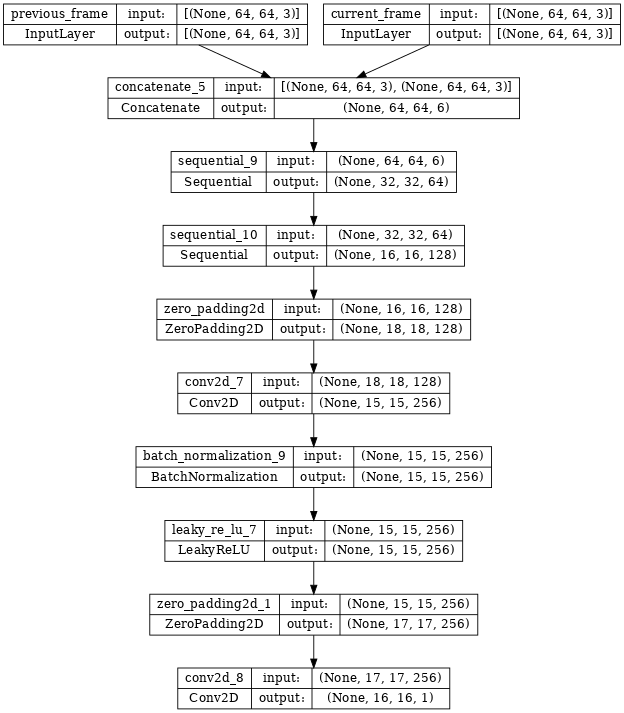

In [6]:
discriminator = get_discriminator_model(IMG_WIDTH, IMG_HEIGHT, N_CHANNELS)
tf.keras.utils.plot_model(discriminator, show_shapes=True, dpi=64, to_file='output/discriminator.png')

In [7]:
generator_loss = GeneratorLoss(MAIN_LOSS,
                lambda_main_loss=LAMBDA1,
                coherence_loss_function=COHERENCE_LOSS,
                lambda_coherence_loss=LAMBDA2,
                landmarks_loss_function=None,
                lambda_landmarks_loss=0,
                landmarks_coherence_loss_function=LANDMARKS_COHERENCE_LOSS,
                lambda_landmarks_coherence_loss=LAMBDA4)

In [8]:
discriminator_loss = DiscriminatorLoss()

In [9]:
generator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)

In [10]:
id_string = ""
if MAIN_LOSS:
    id_string += f"{MAIN_LOSS.__name__}_{LAMBDA1}"
if COHERENCE_LOSS:
    id_string += f"_{COHERENCE_LOSS.__name__}_{LAMBDA2}"
if LANDMARKS_LOSS:
    id_string += f"_{LANDMARKS_LOSS.__name__}_{LAMBDA3}"
if LANDMARKS_COHERENCE_LOSS:
    id_string += f"_{LANDMARKS_COHERENCE_LOSS.__name__}_{LAMBDA4}"
id_string

'l1_loss_1000_l1_loss_200_l1_loss_10'

In [11]:
BASE_DIR = APP_PATH / 'output' / id_string
checkpoint_dir = str(BASE_DIR / 'training_checkpoints')
checkpoint_prefix = os.path.join(checkpoint_dir, "ckpt")
checkpoint = tf.train.Checkpoint(generator_optimizer=generator_optimizer,
                                 discriminator_optimizer=discriminator_optimizer,
                                 generator=generator,
                                 discriminator=discriminator)

## Training


In [12]:
log_dir=BASE_DIR / "logs/"
log_file = log_dir / "fit" / datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

summary_writer = tf.summary.create_file_writer(str(log_file))

In [13]:
def fit(train_dataset_generator, test_dataset_generator, steps):
  pbar = tqdm(range(steps), total=steps)
  for step in pbar:
    with tf.profiler.experimental.Trace('train', step_num=step, _r=1):

      if (step) % 5 == 0:
        clear_output(wait=True)
        display(pbar.container)
        previously_generated, generated_frame, sample_target = test_dataset_generator.generate_next_frame()
        plot_results(sample_target, previously_generated, generated_frame) # TODO: fix input and ground truth are not from the same video

      # train_step(train_dataset_generator, step)
      with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        gen_total_loss, disc_loss, gen_gan_loss, gen_target_predicted, gen_coherence_loss, gen_landmarks_loss, gen_landmarks_coherence_loss = train_dataset_generator.next_loss()
        generator_gradients = gen_tape.gradient(gen_total_loss,
                                                generator.trainable_variables)
        discriminator_gradients = disc_tape.gradient(disc_loss,
                                                    discriminator.trainable_variables)

        generator_optimizer.apply_gradients(zip(generator_gradients,
                                                generator.trainable_variables))
        discriminator_optimizer.apply_gradients(zip(discriminator_gradients,
                                                    discriminator.trainable_variables))
        with summary_writer.as_default():
          tf.summary.scalar(f'gen_total_loss', gen_total_loss, step=step)
          tf.summary.scalar(f'gen_gan_loss', gen_gan_loss, step=step)
          tf.summary.scalar(f'disc_loss', disc_loss, step=step)
          if generator_loss.main_loss_function:
            tf.summary.scalar(f'gen_target_predicted', gen_target_predicted, step=step)
          if generator_loss.coherence_loss_function:
            tf.summary.scalar(f'gen_coherence', gen_coherence_loss, step=step)
          if generator_loss.landmarks_loss_function:
            tf.summary.scalar(f'gen_landmarks_loss', gen_landmarks_loss, step=step)
          if generator_loss.landmarks_coherence_loss_function:
            tf.summary.scalar(f'gen_landmarks_coherence_loss', gen_landmarks_coherence_loss, step=step)
      
      # Save (checkpoint) the model every 5k steps
      if (step + 1) % 50 == 0:
          checkpoint.save(file_prefix=checkpoint_prefix)

In [14]:
train_generator = PreprocessedFrameDataGenerator(train_paths, generator, discriminator, generator_loss, discriminator_loss, repeat=True)
test_generator = PreprocessedFrameDataGenerator(test_paths, generator, discriminator, generator_loss, discriminator_loss)

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


In [15]:
tf.profiler.experimental.start(str(log_dir))

2023-06-16 16:16:35.567127: I tensorflow/tsl/profiler/lib/profiler_session.cc:104] Profiler session initializing.
2023-06-16 16:16:35.567205: I tensorflow/tsl/profiler/lib/profiler_session.cc:119] Profiler session started.


  0%|          | 125/100000 [02:16<28:45:27,  1.04s/it]

Input Sequence


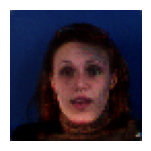

Ground Truth


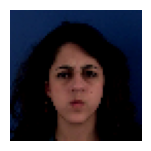

Predicted Sequence


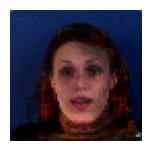

Neutral: 


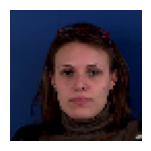

Previous: 


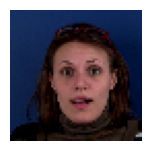

Previous generated: 


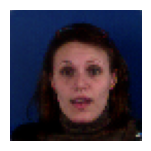

Generated: 


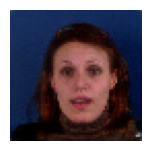

Current: 


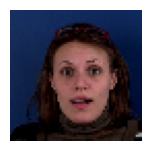

Deformed: 


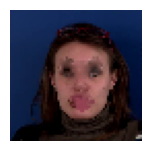

Displacements: 


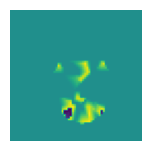

Previous landmarks: 


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


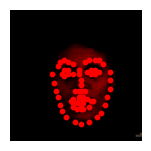

Current landmarks: 


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


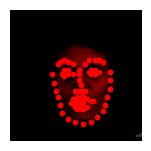

Previous generated landmarks: 


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


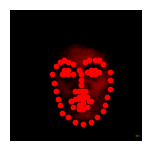

Current generated landmarks: 


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


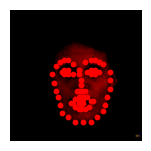

Neutral: 


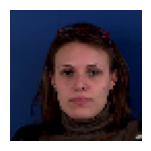

Previous: 


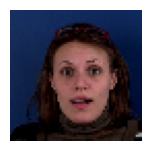

Previous generated: 


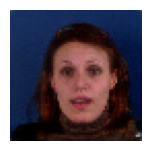

Generated: 


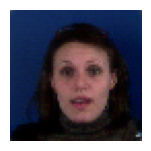

Current: 


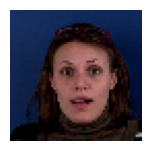

Deformed: 


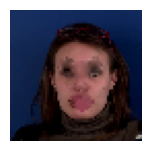

Displacements: 


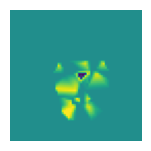

Previous landmarks: 


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


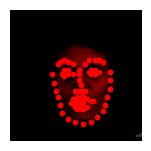

Current landmarks: 


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


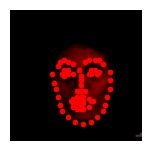

Previous generated landmarks: 


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


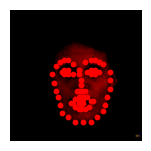

Current generated landmarks: 


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


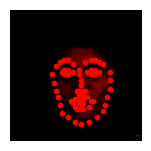

Neutral: 


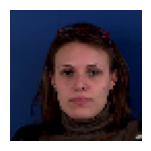

Previous: 


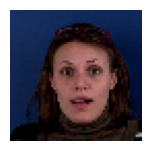

Previous generated: 


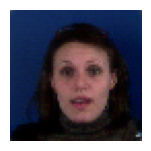

Generated: 


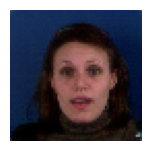

Current: 


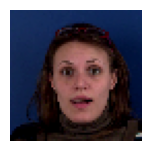

Deformed: 


KeyboardInterrupt: 

<Figure size 2000x400 with 0 Axes>

In [ ]:
fit(train_generator, test_generator, steps=STEPS)

## Restore the latest checkpoint and test the network

In [ ]:
!ls {checkpoint_dir}

In [ ]:
# Restoring the latest checkpoint in checkpoint_dir
checkpoint.restore(tf.train.latest_checkpoint(checkpoint_dir))

## Generate some images using the test set

In [ ]:
test_generator.restart()
for i in range(0,1000,10):
  previously_generated, generated_frame, sample_target = test_generator.generate_next_frame()
  if i % 100 == 0:
    plot_results(sample_target, previously_generated, generated_frame)

In [ ]:
# adapted from https://gist.github.com/lukoshkin/6205455d5b931dcdbd923323003058f0 
# and https://github.com/valerystrizh/mocogan_modified/blob/0860daaa6564b563b5acc1d88f19bac051c1d1c6/src/metrics.py
def acd(frames):
    N = np.multiply.reduce(frames.shape[1:-1])
    res = np.mean(
            np.linalg.norm(
              np.diff(
                np.einsum('ijkl->il', frames), 
              axis=0) / N, 
            axis=1)
          ) 

    return res

def compare_acd(target_sequence, generated_output):
    return np.abs(acd(target_sequence) - acd(generated_output))

In [ ]:
# evaluating the results with SSIM
def evaluate_metrics(target_sequence, generated_output, batch_size):
    unormalize_target_sequence = images_from_normalized(target_sequence)
    unormalize_generated_output = images_from_normalized(generated_output)
    #cast to float32
    target_sequence = tf.cast(target_sequence, tf.float32)
    generated_output = tf.cast(generated_output, tf.float32)
    #compute ssim
    ssim_scores = tf.image.ssim(unormalize_target_sequence, unormalize_generated_output, max_val=255)
    #compute psnr
    psnr_scores = tf.image.psnr(unormalize_target_sequence, unormalize_generated_output, max_val=255)
    #compute mse
    mse_scores = tf.keras.losses.MSE(target_sequence, generated_output)
    #compute l1
    l1_scores = tf.keras.losses.MAE(target_sequence, generated_output)
    # compute fid
    fid_scores = get_frechet_inception_distance(unormalize_target_sequence, unormalize_generated_output, batch_size=batch_size, num_inception_images=batch_size) # TODO: pre frame
    # compute fvd
    # fvd_scores = calculate_fvd(unormalize_target_sequence, unormalize_generated_output)
    # compute acd
    acd_scores = compare_acd(unormalize_target_sequence, unormalize_generated_output) # TODO: per video
    return  {
        "SSIM": tf.reduce_mean(ssim_scores).numpy(),
        "PSNR": tf.reduce_mean(psnr_scores).numpy(),
        "MSE": tf.reduce_mean(mse_scores).numpy(),
        "L1": tf.reduce_mean(l1_scores).numpy(),
        # "FVD": fvd_scores
        "FID": fid_scores.numpy(),
        "ACD": acd_scores
    }


test_n_frames = 1000
test_generator.restart()
predicted_frames = []
target_frames = []

for i in tqdm(range(0, test_n_frames)):
    _, predicted_frame, target_frame = test_generator.generate_next_frame()
    predicted_frames.append(predicted_frame[0])
    target_frames.append(target_frame[0])

predicted_frames = np.array(predicted_frames)
target_frames = np.array(target_frames)

batch_size = 100
scores = []
for i in tqdm(range(0, test_n_frames, batch_size)):
    print(target_frames[i:i+batch_size].shape)
    scores.append(evaluate_metrics(target_frames[i:i+batch_size], predicted_frames[i:i+batch_size], batch_size=batch_size))
  

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

(20, 64, 64, 3)


/usr/local/lib/python3.8/dist-packages/tensorflow/python/util/nest.py:917: UserWarning: `tf.layers.flatten` is deprecated and will be removed in a future version. Please use `tf.keras.layers.Flatten` instead.
  structure[0], [func(*x) for x in entries],


(20, 64, 64, 3)
(20, 64, 64, 3)
(20, 64, 64, 3)
(20, 64, 64, 3)


In [ ]:
len(scores)
df = pd.DataFrame(scores)
df.to_csv(f"{log_dir}/metrics.csv")
print(df)

       SSIM       PSNR       MSE        L1         FID       ACD
0  0.353163  19.900234  0.041496  0.140715  385.054474  0.004449
1  0.349873  19.822546  0.042236  0.142105  407.225159  0.005981
2  0.326353  19.736446  0.043063  0.144190  376.072815  0.003550
3  0.285952  19.064442  0.050188  0.154347  341.332611  0.000939
4  0.323556  19.774277  0.042697  0.143082  343.577545  0.004758


In [ ]:
print(df.mean())

SSIM      0.327779
PSNR     19.659588
MSE       0.043936
L1        0.144888
FID     370.652527
ACD       0.003935
dtype: float64


## Different order

In [ ]:
new_order = [0, 10, 1, 11, 2, 12, 3, 13, 4, 14, 5, 15, 6, 16, 7, 17, 8, 18, 9]

# # Run the trained model on a few examples from the test set
# for i, (inp, tar) in enumerate(test_dataset.take(5)):
#   inp = tf.gather(inp, new_order, axis=-1)
#   tar = tf.gather(tar, new_order, axis=-1)
#   # inp = inp[..., new_order]
#   # tar = tar[..., new_order]
#   tf.print(i)
#   generate_sequences(generator, inp, tar, save_dir=save_dir)